# Analysis of Counted Cells

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# --- plotting style (matplotlib only) ---
plt.rcParams.update({
    "figure.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "0.15",
    "axes.linewidth": 0.8,
    "axes.titleweight": "bold",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.6,
})

# --- create compact frame index that aligns the two halves ---
uids = np.array(sorted(out['frameID'].dropna().astype(int).unique()))
n = len(uids)
half = max(1, n // 2)
idx_map = {fid: i % half for i, fid in enumerate(uids)}
out = out.copy()
out['frame_idx'] = out['frameID'].astype(int).map(idx_map)

# --- numeric columns and y limit with headroom rounded to nearest 5 ---
num = out[['viability_eff','viability_ctrl','normalized_pct']].apply(pd.to_numeric, errors='coerce')
raw_max = float(num.max().max()) if pd.notna(num.max().max()) else 100.0
ymax = max(raw_max, 100.0)
ymax = np.ceil((ymax * 1.05) / 5.0) * 5.0  # 5% headroom, round up to nearest 5

# --- plotting parameters (matplotlib colors) ---
colors = {"eff": "#2ca02c", "ctrl": "#1f77b4", "norm": "#ff7f0e"}  # green, blue, orange
markersize = 6
markeredgewidth = 0.8
markeredgecolor = "k"

# --- create vertical subplots ---
conds = out['condition'].dropna().unique()
N = len(conds)
fig, axs = plt.subplots(N, 1, figsize=(8, 2.2 * max(1, N)), sharex=True)
if N == 1:
    axs = [axs]

for ax, cond in zip(axs, conds):
    dfc = out.loc[out['condition'] == cond].sort_values('frame_idx')
    x = dfc['frame_idx'].values

    ax.plot(x, pd.to_numeric(dfc['viability_eff'], errors='coerce'),
            marker='o', markersize=markersize, markeredgewidth=markeredgewidth,
            markeredgecolor=markeredgecolor, color=colors["eff"], label='1 Effector')
    ax.plot(x, pd.to_numeric(dfc['viability_ctrl'], errors='coerce'),
            marker='s', markersize=markersize, markeredgewidth=markeredgewidth,
            markeredgecolor=markeredgecolor, color=colors["ctrl"], label='No Effector')
    ax.plot(x, pd.to_numeric(dfc['normalized_pct'], errors='coerce'),
            marker='^', markersize=markersize, markeredgewidth=markeredgewidth,
            markeredgecolor=markeredgecolor, color=colors["norm"], label='Normalized')

    ax.set_ylim(0, ymax)
    ax.set_ylabel("Viability (%)")
    ax.set_title(str(cond), pad=6)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)

    # keep only left and bottom spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    ax.set_xlim(-0.5, half - 0.5)
    ax.set_xticks(list(range(half)))

# unified legend centered above subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

# show x tick labels only on bottom axis
for a in axs[:-1]:
    a.set_xticklabels([])
axs[-1].set_xlabel("Frame index (modulo)")
axs[-1].tick_params(axis='x', which='major', labelsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space for legend

# save publication-quality PDF in experiment folder
out_file = Path(RawLoader(expID).exp_dir) / f"{expID}_viability.pdf"
fig.savefig(out_file, dpi=300, bbox_inches='tight')
print("Saved figure to:", out_file)

plt.show()

Repo root: /Users/xiangxigao/Desktop/git/droplet-phenotyping
['/Users/xiangxigao/Desktop/git/droplet-phenotyping', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python312.zip', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python3.12', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python3.12/lib-dynload', '']


In [10]:
import matplotlib.pyplot as plt
from Analysis.utilities import get_bubble, prepare_data
from Tools.leica_tools import RawLoader
from Tools.sample_tools import Sample
import pandas as pd

### Encapsulation Efficiency - Bubble Plot

number of Effector: 86
number of dead Effector: 0
number of Total Effector: 86
number of Target: 3267
number of dead Target: 1407
number of Total Target: 4674


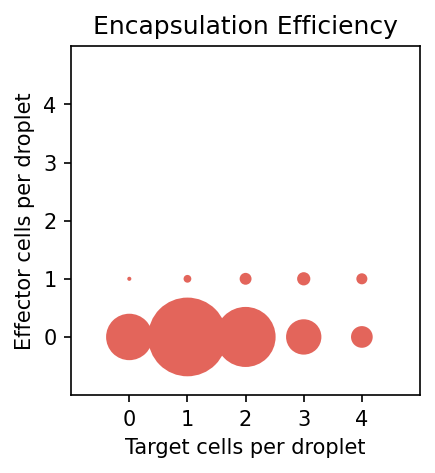

In [6]:
expID = "TECH_XG_009"
droplet_df = prepare_data(RawLoader(expID).get_droplet_df(), 'cell_count_v3')

data = droplet_df.query('outlier == False and frameID == 0').copy() #outlier == False
cols = ['Effector', 'dead_Effector', 'Total_Effector', 
        'Target', 'dead_Target', 'Total_Target']

for col in cols:
    print(f'number of {col.replace("_", " ")}: {sum(data[col])}')

fig, (ax) = plt.subplots(1, 1, figsize=(3, 5), dpi=150)
ax, matrix = get_bubble(data, ax, factor=30)
ax.set_aspect('equal')
ax.set_title("Encapsulation Efficiency")
plt.tight_layout()
plt.show()


### Target viability

In [11]:
# count number of outlier droplets and number of droplets with 2-3 target cells and 0-1 effector cells
droplet_df = prepare_data(RawLoader(expID).get_droplet_df(), 'cell_count_v3')
print(droplet_df["outlier"].value_counts())

viab_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector <= 1').copy()
print(viab_df["outlier"].value_counts())

# groupby frame ID and sum dead_Target and Total_Target, then calculate viability
viab_df = viab_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
viab_df = viab_df.query('frameID <= 60')
viab_df['viability (%)'] = 100 * (1 - viab_df['dead_Target'] / viab_df['Total_Target'])

# calculate viability for each frame and print it

for _, row in viab_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    viability = 100 * (1 - dead / total) if total != 0 else 0
    #print(f"ID {int(row['frameID'])}: {int(dead)} / {int(total)} dead = {viability:.2f}% viability")

norm_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector == 1').copy()#outlier == False 
norm_df = norm_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
norm_df = norm_df.query('frameID <= 60')
norm_df['viability (%)'] = 100 * (1 - norm_df['dead_Target'] / norm_df['Total_Target'])

for _, row in norm_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    norm_viability = 100 * (1 - dead / total) if total != 0 else 0

# normalise viab_df with norm_df

viab_df['normalized viability (%)'] = viab_df['viability (%)'] / norm_df['viability (%)'] * 100

viab_df



outlier
False    72210
True      2938
Name: count, dtype: Int64
outlier
False    26503
Name: count, dtype: Int64


,frameID,dead_Target,Total_Target,viability (%),normalized viability (%)
0,0,851,2647,67.850397,122.65264
1,1,1032,2590,60.15444,116.549228
2,2,990,2533,60.91591,115.063386
3,3,1047,2444,57.160393,111.598862
4,4,1072,2342,54.227156,111.16567
5,5,1102,2240,50.803571,113.703231
6,6,1083,2094,48.280802,120.418001
7,7,1114,2069,46.157564,106.708347
8,8,1069,1974,45.845998,106.217461
9,9,1068,1877,43.100693,93.318931


outlier
False    72210
True      2938
Name: count, dtype: Int64
outlier
False    23302
Name: count, dtype: Int64


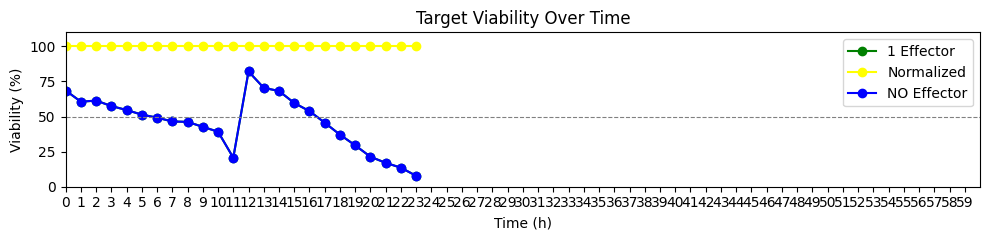

frameID	1 Effector Viability (%)	NO Effector Viability (%)	Normalized Viability (%)
0	68.56	68.56	100.00
1	60.58	60.58	100.00
2	61.37	61.37	100.00
3	57.48	57.48	100.00
4	54.64	54.64	100.00
5	51.36	51.36	100.00
6	49.20	49.20	100.00
7	46.49	46.49	100.00
8	46.21	46.21	100.00
9	42.66	42.66	100.00
10	39.20	39.20	100.00
11	20.66	20.66	100.00
12	82.09	82.09	100.00
13	70.44	70.44	100.00
14	68.21	68.21	100.00
15	59.64	59.64	100.00
16	53.86	53.86	100.00
17	45.62	45.62	100.00
18	37.08	37.08	100.00
19	29.47	29.47	100.00
20	21.35	21.35	100.00
21	17.01	17.01	100.00
22	13.56	13.56	100.00
23	7.76	7.76	100.00


In [ ]:

droplet_df = prepare_data(RawLoader(expID).get_droplet_df(), 'cell_count_v3')
print(droplet_df["outlier"].value_counts())

viab_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector == 0').copy()
print(viab_df["outlier"].value_counts())

viab_df = viab_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
viab_df = viab_df.query('frameID <= 60')
viab_df['viability (%)'] = 100 * (1 - viab_df['dead_Target'] / viab_df['Total_Target'])

for _, row in viab_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    viability = 100 * (1 - dead / total) if total != 0 else 0
    #print(f"ID {int(row['frameID'])}: {int(dead)} / {int(total)} dead = {viability:.2f}% viability")

norm_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector == 0').copy()#outlier == False 
norm_df = norm_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
norm_df = norm_df.query('frameID <= 60')
norm_df['viability (%)'] = 100 * (1 - norm_df['dead_Target'] / norm_df['Total_Target'])

for _, row in norm_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    norm_viability = 100 * (1 - dead / total) if total != 0 else 0

# normalise viab_df with norm_df
viab_df['normalized viability (%)'] = viab_df['viability (%)'] / norm_df['viability (%)'] * 100

# Plot viability
fig, (ax) = plt.subplots(1, 1, figsize=(10, 2.5), dpi=100)
ax.plot(viab_df['frameID'], viab_df['viability (%)'], marker='o', color='green', label='1 Effector')
ax.plot(viab_df['frameID'], viab_df['normalized viability (%)'], marker='o', color='yellow', label='Normalized')
ax.plot(norm_df['frameID'], norm_df['viability (%)'], marker='o', color='blue', label='NO Effector')
ax.set_ylim(0, 110)  # 10% headroom
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)  # Add 50% line
ax.set_xlim(0, 60)
ax.set_xticks(range(60))  # Hour ticks: 0 to 9
ax.set_xlabel("Time (h)")
ax.set_ylabel("Viability (%)")
ax.set_title("Target Viability Over Time")
ax.legend() 
plt.tight_layout()
plt.show()

# print all values for 1 Effector and Normalized and NO Effector as table i can copy into excel
print("frameID\t1 Effector Viability (%)\tNO Effector Viability (%)\tNormalized Viability (%)")
for _, row in viab_df.iterrows():
    frameID = int(row['frameID'])
    effector_viability = row['viability (%)']
    normalized_viability = row['normalized viability (%)']
    try:
        no_effector_viability = norm_df.query(f'frameID == {frameID}')['viability (%)'].values[0]
    except IndexError:
        no_effector_viability = 0
    print(f"{frameID}\t{effector_viability:.2f}\t{no_effector_viability:.2f}\t{normalized_viability:.2f}")


In [16]:
# print all values for 1 Effector and Normalized and NO Effector as table i can copy into excel
print("frameID\t1 Effector Viability (%)\tNO Effector Viability (%)\tNormalized Viability (%)")
print("-" * 100)
for _, row in viab_df.iterrows():
    frameID = int(row['frameID'])
    effector_viability = row['viability (%)']
    normalized_viability = row['normalized viability (%)']
    try:
        no_effector_viability = norm_df.query(f'frameID == {frameID}')['viability (%)'].values[0]
    except IndexError:
        no_effector_viability = 0
    print(f"{frameID:<8}\t{effector_viability:>8.2f}\t{no_effector_viability:>8.2f}\t{normalized_viability:>8.2f}")

# Save to CSV

# 1) load authoritative frame list (frameID as column) from setup.xlsx
raw = pd.read_excel(Path(RawLoader(expID).exp_dir) / "setup.xlsx", sheet_name="raw_data", index_col=0).reset_index().rename(columns={"index":"frameID"})[["frameID","condition"]]

# 2) prepare per-frame tables (ensure column names match: 'frameID' and 'viability (%)')
viab = viab_df[['frameID','viability (%)']].rename(columns={'viability (%)':'viability_eff'})
norm = norm_df[['frameID','viability (%)']].rename(columns={'viability (%)':'viability_ctrl'})

# 3) outer-join using the setup raw_data (frameID+condition), compute normalized safely, save TSV
out = raw.merge(viab, on='frameID', how='left').merge(norm, on='frameID', how='left')
out['normalized_pct'] = out.apply(lambda r: (r['viability_eff']/r['viability_ctrl']*100) if pd.notna(r['viability_eff']) and pd.notna(r['viability_ctrl']) and r['viability_ctrl']!=0 else pd.NA, axis=1)
out.to_csv(Path(RawLoader(expID).exp_dir)/f"{expID}_viability_table.csv", sep=',', index=False)
print("Wrote", Path(RawLoader(expID).exp_dir)/f"{expID}_viability_table.csv")


frameID	1 Effector Viability (%)	NO Effector Viability (%)	Normalized Viability (%)
----------------------------------------------------------------------------------------------------
0       	   67.85	   55.32	  122.65
1       	   60.15	   51.61	  116.55
2       	   60.92	   52.94	  115.06
3       	   57.16	   51.22	  111.60
4       	   54.23	   48.78	  111.17
5       	   50.80	   44.68	  113.70
6       	   48.28	   40.09	  120.42
7       	   46.16	   43.26	  106.71
8       	   45.85	   43.16	  106.22
9       	   43.10	   46.19	   93.32
10      	   39.72	   43.24	   91.86
11      	   20.50	   19.73	  103.91
12      	   80.33	   54.95	  146.18
13      	   69.06	   52.66	  131.15
14      	   66.89	   53.05	  126.09
15      	   59.00	   54.33	  108.61
16      	   52.30	   41.73	  125.33
17      	   44.80	   41.32	  108.42
18      	   35.73	   30.00	  119.11
19      	   28.42	   24.45	  116.22
20      	   20.70	   18.73	  110.56
21      	   15.86	   13.01	  121.89
22      	   12.74	   10

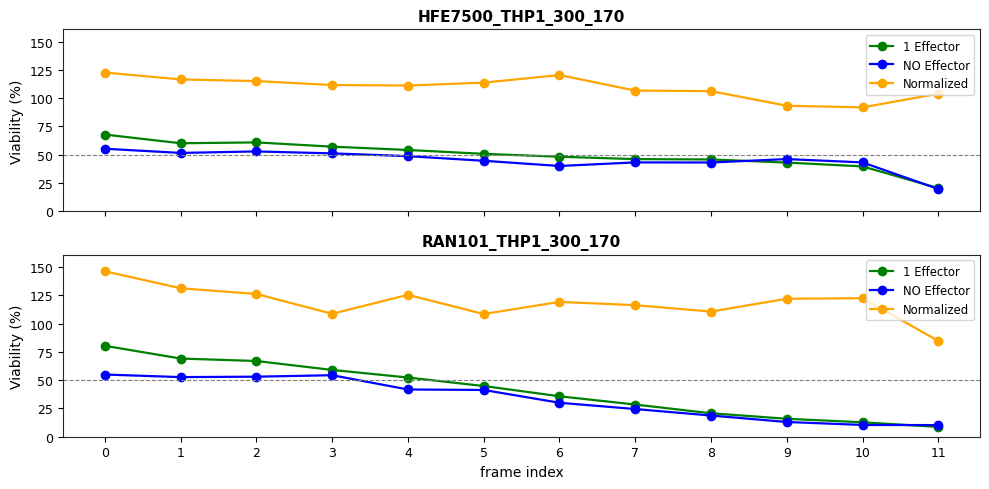

Saved figure to: /Users/xiangxigao/Desktop/git/droplet-phenotyping/Experiments/TECH_XG_009/TECH_XG_009_HFE7500_THP1_300_170_RAN101_THP1_300_170_viability.png


In [29]:
# --- create a compact frame index that aligns the two halves ---
uids = np.array(sorted(out['frameID'].dropna().astype(int).unique()))
n = len(uids)
half = max(1, n // 2)
idx_map = {fid: i % half for i, fid in enumerate(uids)}            # map original frameID -> frame_idx
out = out.copy()
out['frame_idx'] = out['frameID'].astype(int).map(idx_map)

# --- make numeric copies and compute y limit as the max viability in out ---
num = out[['viability_eff','viability_ctrl','normalized_pct']].apply(pd.to_numeric, errors='coerce')
ymax = float(num.max().max()) if pd.notna(num.max().max()) else 100.0

# --- plotting ---
conds = out['condition'].dropna().unique()
N = len(conds)
fig, axs = plt.subplots(N, 1, figsize=(10, 2.5 * max(1, N)), sharex=True, dpi=100)
if N == 1:
    axs = [axs]

for ax, cond in zip(axs, conds):
    dfc = out.loc[out['condition'] == cond].sort_values('frame_idx')
    x = dfc['frame_idx'].values
    ax.plot(x, pd.to_numeric(dfc['viability_eff'], errors='coerce'), marker='o', color='green', label='1 Effector')
    ax.plot(x, pd.to_numeric(dfc['viability_ctrl'], errors='coerce'), marker='o', color='blue',  label='NO Effector')
    ax.plot(x, pd.to_numeric(dfc['normalized_pct'], errors='coerce'), marker='o', color='orange', label='Normalized')
    ax.set_ylim(0, ymax*1.1)                     # set y-limit to max viability in out
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel("Viability (%)")
    ax.set_title(str(cond))
    ax.legend(loc='upper right', fontsize='small')

# hide tick labels (no hour ticks). keep tick positions 0..half-1 for alignment
ticks = list(range(half))
for ax in axs:
    ax.set_xticks(ticks)
    ax.set_xticklabels([])

# optionally show numeric tick labels only on the bottom subplot:
axs[-1].set_xticklabels(ticks)
axs[-1].set_xlabel("frame index")

plt.tight_layout()
plt.show()

# Save the plot as PNG with expID and conditions in filename
conditions_str = '_'.join(conds)
out_file = Path(RawLoader(expID).exp_dir) / f"{expID}_{conditions_str}_viability.png"
fig.savefig(out_file, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {out_file}")

### Killing Pies from .csv

In [100]:
# Common filters for ALL conditions
COMMON_QUERY = (
    'outlier == False'
    '& time == 6'
    '& Total_Target >= 2'
    '& Total_Target <= 4'
)

condition_names = {
    '33-4-CAR':         '33-4-CAR_THP1',
    '33-CAR':           '33-CAR_THP1',
    '4-CAR':            '4-CAR_THP1',
    'Mesothelin-CAR':   'Mesothelin-CAR_THP1'
}

# Build the two query dictionaries
conditions = {
    name: f'{COMMON_QUERY} & condition == "{condition}" & Total_Effector == 1'
    for name, condition in condition_names.items()
}

control_condition = {
    name: f'{COMMON_QUERY} & condition == "{condition}" & Total_Effector == 0'
    for name, condition in condition_names.items()
}

33-4-CAR - Effector: mono=0.284, serial=0.227, none=0.4896
33-4-CAR - Control: mono=0.120, serial=0.053, none=0.8273
33-4-CAR - Normalized: mono=0.164, serial=0.174, none=0.6623
33-CAR - Effector: mono=0.233, serial=0.159, none=0.6076
33-CAR - Control: mono=0.138, serial=0.018, none=0.8436
33-CAR - Normalized: mono=0.095, serial=0.141, none=0.7641
4-CAR - Effector: mono=0.295, serial=0.238, none=0.4676
4-CAR - Control: mono=0.146, serial=0.050, none=0.8050
4-CAR - Normalized: mono=0.149, serial=0.188, none=0.6626
Mesothelin-CAR - Effector: mono=0.149, serial=0.010, none=0.8414
Mesothelin-CAR - Control: mono=0.128, serial=0.009, none=0.8627
Mesothelin-CAR - Normalized: mono=0.021, serial=0.000, none=0.9787


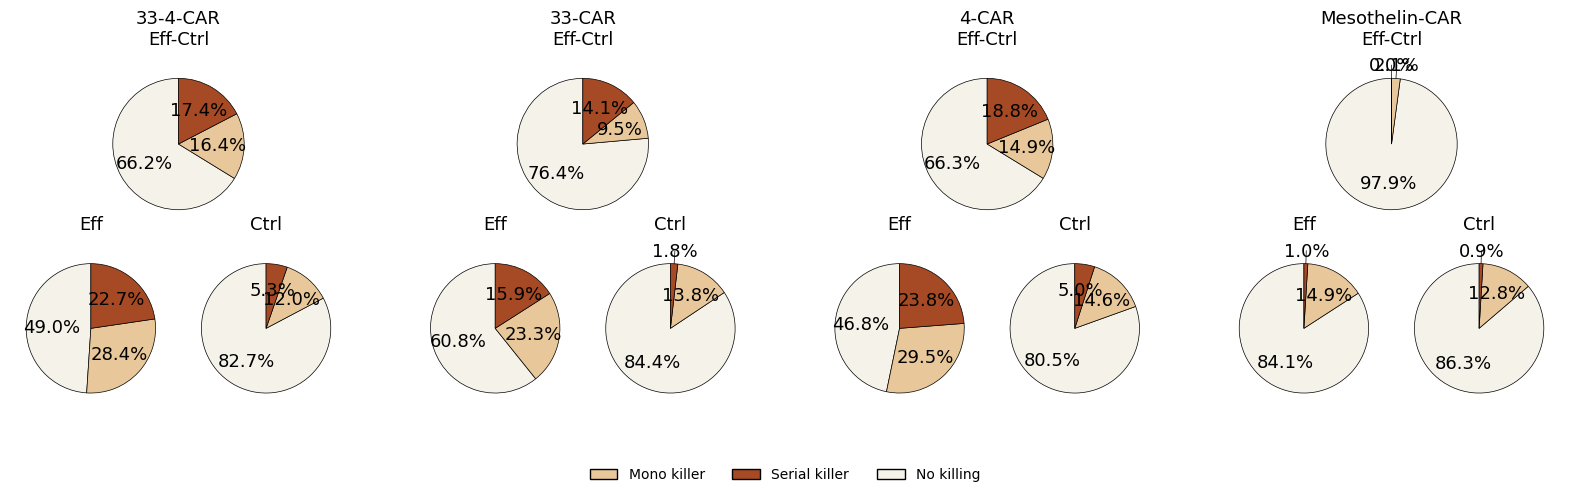

Dataframe lengths for each condition:
33-4-CAR: Effector count = 966, Control count = 1587
33-CAR: Effector count = 734, Control count = 1419
4-CAR: Effector count = 1110, Control count = 1333
Mesothelin-CAR: Effector count = 725, Control count = 1267
Droplets before: 241497


In [101]:
import matplotlib.pyplot as plt
from helpers_pies import draw_pie

fig, axs = plt.subplots(ncols=len(conditions), figsize=(20, 5), sharey=True)
plt.subplots_adjust(bottom=0.15, wspace=0.2)


samples_to_plot = {
    'CARK_JB_035': 'outlier == False'
}

colors = ['#E8C89B','#A54A24','#F5F2E9']
len_dataframes = []


for expID, sample_query in samples_to_plot.items():

    droplet_df = prepare_data(RawLoader(expID).get_droplet_df(),'cell_count_v3')

    for j, (condition_name, query) in enumerate(conditions.items()):

        eff_df = droplet_df.query(query)
        ctrl_df = droplet_df.query(control_condition[condition_name])
        len_dataframes.append((condition_name, len(eff_df), len(ctrl_df)))

        # counts
        mono_eff = eff_df.query('dead_Target == 1').shape[0]
        serial_eff = eff_df.query('dead_Target >= 2').shape[0]

        mono_ctrl = ctrl_df.query('dead_Target == 1').shape[0]
        serial_ctrl = ctrl_df.query('dead_Target >= 2').shape[0]

        eff_total = len(eff_df)
        ctrl_total = len(ctrl_df)


        # percentages
        mono_eff_pct = mono_eff / eff_total if eff_total else 0
        serial_eff_pct = serial_eff / eff_total if eff_total else 0
        mono_ctrl_pct = mono_ctrl / ctrl_total if ctrl_total else 0
        serial_ctrl_pct = serial_ctrl / ctrl_total if ctrl_total else 0

        # raw pies
        eff_values = [mono_eff_pct, serial_eff_pct, max(0, 1 - mono_eff_pct - serial_eff_pct)]
        ctrl_values = [mono_ctrl_pct, serial_ctrl_pct, max(0, 1 - mono_ctrl_pct - serial_ctrl_pct)]

        # normalized pie
        mono_norm = max(0, mono_eff_pct - mono_ctrl_pct)
        serial_norm = max(0, serial_eff_pct - serial_ctrl_pct)
        norm_values = [mono_norm, serial_norm, max(0, 1 - mono_norm - serial_norm)]
        print(f"{condition_name} - Effector: mono={mono_eff_pct:.3f}, serial={serial_eff_pct:.3f}, none={1 - mono_eff_pct - serial_eff_pct:.4f}")
        print(f"{condition_name} - Control: mono={mono_ctrl_pct:.3f}, serial={serial_ctrl_pct:.3f}, none={1 - mono_ctrl_pct - serial_ctrl_pct:.4f}")
        print(f"{condition_name} - Normalized: mono={mono_norm:.3f}, serial={serial_norm:.3f}, none={max(0, 1 - mono_norm - serial_norm):.4f}") 

        # layout
        ax_norm = axs[j].inset_axes([0.25, 0.52, 0.50, 0.45])
        ax_eff_raw = axs[j].inset_axes([0.00, 0.00, 0.48, 0.48])
        ax_ctrl_raw = axs[j].inset_axes([0.52, 0.00, 0.48, 0.48])

        # plot pies
        draw_pie(ax_eff_raw, mono_eff_pct, serial_eff_pct, 'Eff')
        draw_pie(ax_ctrl_raw, mono_ctrl_pct, serial_ctrl_pct, 'Ctrl')
        draw_pie(ax_norm, mono_norm, serial_norm, 'Eff-Ctrl')

        axs[j].set_title(condition_name,fontsize=13,pad=20)
        axs[j].axis('off')


# legend
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label='Mono killer'),
    Patch(facecolor=colors[1], edgecolor='black', label='Serial killer'),
    Patch(facecolor=colors[2], edgecolor='black', label='No killing')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    frameon=False
)
plt.show()

print("Dataframe lengths for each condition:")
for condition_name, eff_len, ctrl_len in len_dataframes:
    print(f"{condition_name}: Effector count = {eff_len}, Control count = {ctrl_len}")
print("Droplets before:", len(droplet_df))